=== Проверим риски переобучения ===
=== Train ===
R²:   0.9989
MAPE: 2.57%
=== Val ===
R²:   0.998259566092279
MAPE: 3.0772260177790134%
RMSE: 82.48545926449835 кг


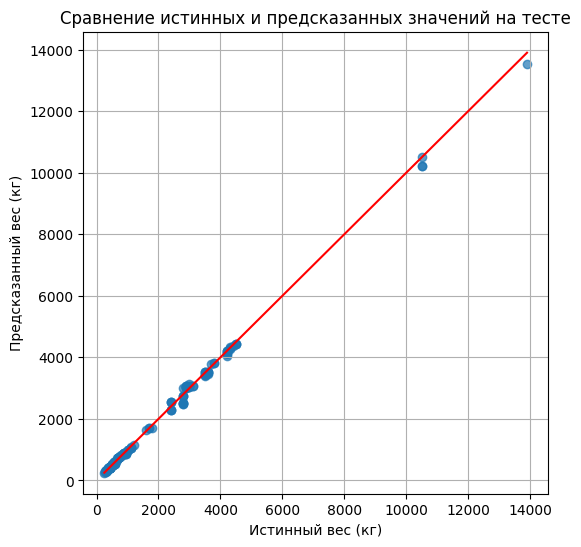

=== Тест ===
R²:   0.6783
MAPE: 35.49%
RMSE: 1751.24 кг


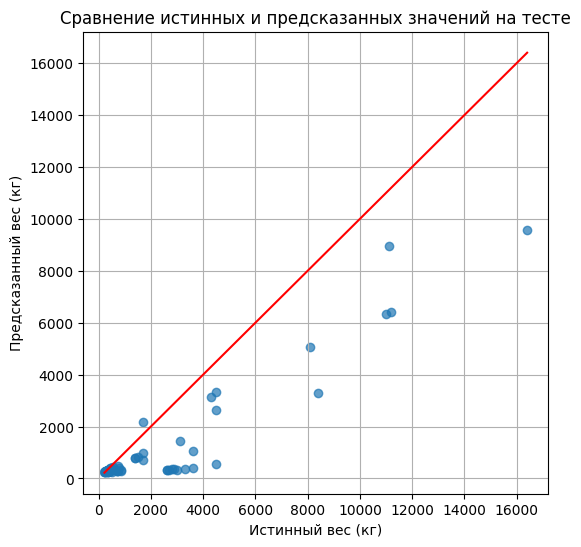

=== Train признаки ===
           0        1        2       3       4       5       6         7   \
count  748.00   748.00   748.00  748.00  748.00  748.00  748.00    748.00   
mean   123.99   316.16  2927.94  116.88    1.00    0.00    8.50   9631.80   
std    177.24   380.49   788.32   70.93    0.45    0.00    1.35  10109.62   
min      1.00    10.00  1800.00   15.00    0.20    0.00    4.62    100.00   
25%     13.00    43.33  1800.00   50.00    0.70    0.00    7.71   2222.22   
50%     30.00    80.00  3500.00  100.00    1.10    0.00    8.69   5950.00   
75%    120.00   550.00  3600.00  200.00    1.30    0.01    9.57  14355.56   
max    600.00  1150.00  3600.00  200.00    2.00    0.01   10.78  48000.00   

               8         9   ...         18       19      20        21  \
count      748.00    748.00  ...     748.00   748.00  748.00    748.00   
mean    301195.59  11733.62  ...  375167.11  2853.70   14.58  25001.89   
std     430685.43  17921.71  ...  272705.14  1571.99   10.19 

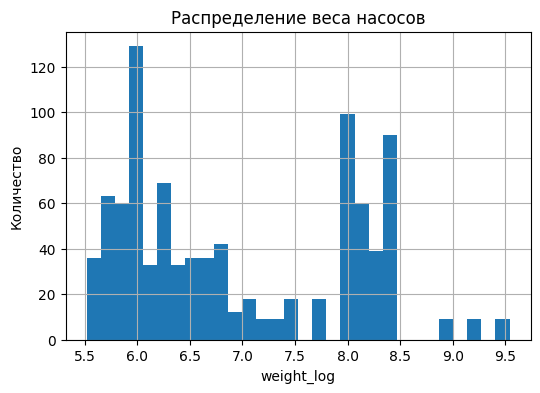

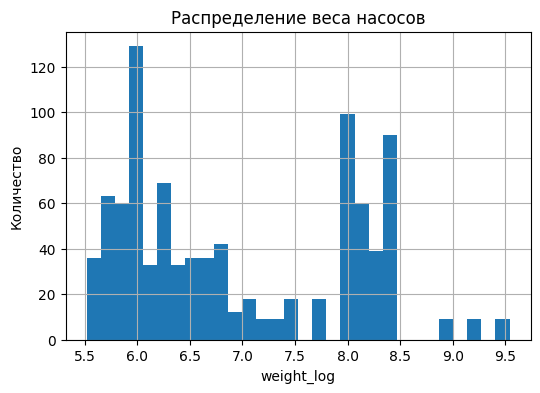

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

df = pd.read_csv("dataset_ml (6).csv")
feature_cols = ["flow_rate", "fluid_head", "rpm", "spec_gravity", "power_kw", "diameter_proxy", "useful_kw_log"]
#tag,rpm,spec_gravity,power_kw,pump_eff,useful_kw,weight_log
X = df[feature_cols]
y = df["weight_log"]

# делаим датасет на две выборки (обучение и валидация), тестовые данные отдельным файлом
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# используем полиномиальные признаки
poly = PolynomialFeatures(2, include_bias = False, interaction_only = True)
X_train = poly.fit_transform(X_train)
X_val = poly.transform(X_val)

#GradientBoostingRegressor
model_gb = GradientBoostingRegressor(n_estimators=300, max_depth=2, learning_rate=0.05, random_state=42)
model_gb.fit(X_train, y_train)

# Метрики на train (для проверки на переобучение)
y_pred_train = model_gb.predict(X_train)
y_train_kg = np.exp(y_train)
y_pred_train_kg = np.exp(y_pred_train)

print("=== Проверим риски переобучения ===")
print("=== Train ===")
print(f"R²:   {r2_score(y_train_kg, y_pred_train_kg):.4f}")
print(f"MAPE: {np.mean(np.abs((y_train_kg - y_pred_train_kg) / y_train_kg)) * 100:.2f}%")

y_pred_gb = model_gb.predict(X_val)
# Переводим обратно в кг
y_pred_kg = np.exp(y_pred_gb)
y_val_kg = np.exp(y_val)

# Метрики в кг при валидации
rmse_kg = np.sqrt(mean_squared_error(y_val_kg, y_pred_kg))
r2_kg   = r2_score(y_val_kg, y_pred_kg)
mape    = np.mean(np.abs((y_val_kg - y_pred_kg) / y_val_kg)) * 100

print("=== Val ===")
print(f"R²:   {r2_kg}")
print(f"MAPE: {mape}%")
print(f"RMSE: {rmse_kg} кг")

# График тоже в кг
plt.figure(figsize=(6, 6))
plt.scatter(y_val_kg, y_pred_kg, alpha=0.7)
plt.plot([y_val_kg.min(), y_val_kg.max()],
         [y_val_kg.min(), y_val_kg.max()], color="red")
plt.xlabel("Истинный вес (кг)")
plt.ylabel("Предсказанный вес (кг)")
plt.title("Сравнение истинных и предсказанных значений на тесте")
plt.grid(True)
plt.show()

df_test = pd.read_csv("dataset_inference (7).csv")
feature_cols = ["flow_rate", "fluid_head", "rpm", "spec_gravity", "power_kw", "diameter_proxy", "useful_kw_log"]
X_test = df_test[feature_cols]
y_test = df_test["weight_log"]

X_test = poly.transform(X_test)

# метрики и графки по тестовым данным
y_pred_test = model_gb.predict(X_test)
y_test_kg = np.exp(y_test)
y_pred_test_kg = np.exp(y_pred_test)

print("=== Тест ===")
print(f"R²:   {r2_score(y_test_kg, y_pred_test_kg):.4f}")
print(f"MAPE: {np.mean(np.abs((y_test_kg - y_pred_test_kg) / y_test_kg)) * 100:.2f}%")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_kg, y_pred_test_kg)):.2f} кг")

# График тоже в кг
plt.figure(figsize=(6, 6))
plt.scatter(y_test_kg, y_pred_test_kg, alpha=0.7)
plt.plot([y_test_kg.min(), y_test_kg.max()], [y_test_kg.min(), y_test_kg.max()], color="red")
plt.xlabel("Истинный вес (кг)")
plt.ylabel("Предсказанный вес (кг)")
plt.title("Сравнение истинных и предсказанных значений на тесте")
plt.grid(True)
plt.show()

print("=== Train признаки ===")
print(pd.DataFrame(X_train).describe().round(2))

print("=== Test признаки ===")
print(X_test_raw := df_test[feature_cols])
print(X_test_raw.describe().round(2))

print("=== Train таргет (weight_log) ===")
print(y_train.describe())

print("=== Test таргет (weight_log) ===")
print(y_test.describe())

plt.figure(figsize=(6, 4))
df["weight_log"].hist(bins=30)
plt.xlabel("weight_log")
plt.ylabel("Количество")
plt.title("Распределение веса насосов")
plt.grid(True)
plt.show()

dp = pd.read_csv("dataset_ml (6).csv")
plt.figure(figsize=(6, 4))
dp["weight_log"].hist(bins=30)
plt.xlabel("weight_log")
plt.ylabel("Количество")
plt.title("Распределение веса насосов")
plt.grid(True)
plt.show()